<a href="https://colab.research.google.com/github/calebriggs1120/CIS-3902-AI-ML--Caleb-Schell/blob/main/Mushroom_Reduced_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mushroom Decision Tree (Reduced Features) — Student Exercise
## Your Name: Caleb Schell
## Date: 3/2/2026
### In Blackboard you will submit your Github URL after saving your notebook to your class repository, AND a PDF of this notebook (in Colab, File . . . Print . . . PDF)
This activity uses a simplified version of the Mushroom dataset to create a decision tree.

## Goals
- Build a decision tree classifier
- Interpret a confusion matrix and accuracy
- Explain what the root and first-level nodes mean
- Translate tree splits into plain English


## 1️⃣ Setup

In [14]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


## 2️⃣ Load the Mushroom dataset (code is completed for you)
**Target:** `class`
- `e` = edible which becomes 0 or not poisonous
- `p` = poisonous which becomes 1

In [2]:
#note feature names, we will reduce these
mush = fetch_openml('mushroom', version=1, as_frame=True)
df = mush.frame.copy()
# rename the column
df = df.rename(columns={"bruises%3F": "bruises"})
df.head()


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


## 3️⃣ Use a reduced feature set (code is completed for you)
These features are highly predictive and keep the tree readable. Note the class is mapped to 0 (edible) and 1 (poisonous).

In [3]:

features = ['odor', 'spore-print-color', 'gill-size', 'gill-color', 'bruises']

X = df[features]
y = df['class'].map({'e':0, 'p':1})

X.head(), y.value_counts()


(  odor spore-print-color gill-size gill-color bruises
 0    p                 k         n          k       t
 1    a                 n         b          k       t
 2    l                 n         b          n       t
 3    p                 k         n          n       t
 4    n                 n         b          k       f,
 class
 0    4208
 1    3916
 Name: count, dtype: int64)

## 4️⃣ One‑hot encode the categorical features (Add Code)
Each category becomes a YES/NO column.

In [4]:

X = pd.get_dummies(X, columns=['odor', 'spore-print-color', 'gill-size', 'gill-color', 'bruises'], prefix_sep=" = ")
X.head()


,odor = a,odor = c,odor = f,odor = l,odor = m,odor = n,odor = p,odor = s,odor = y,spore-print-color = b,...,gill-color = k,gill-color = n,gill-color = o,gill-color = p,gill-color = r,gill-color = u,gill-color = w,gill-color = y,bruises = f,bruises = t
0,False,False,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
1,True,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,False,False,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True
4,False,False,False,False,False,True,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False


## 5️⃣ Train/test split (Add Code)

In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

## 6️⃣ Train a small decision tree (Add Code)

In [22]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)



DecisionTreeClassifier(max_depth=5, random_state=42)

## 7️⃣ Evaluate the model (Add Code)

In [23]:

pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))


Accuracy: 0.995

Confusion Matrix:
 [[1052    0]
 [  10  969]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1052
           1       1.00      0.99      0.99       979

    accuracy                           1.00      2031
   macro avg       1.00      0.99      1.00      2031
weighted avg       1.00      1.00      1.00      2031



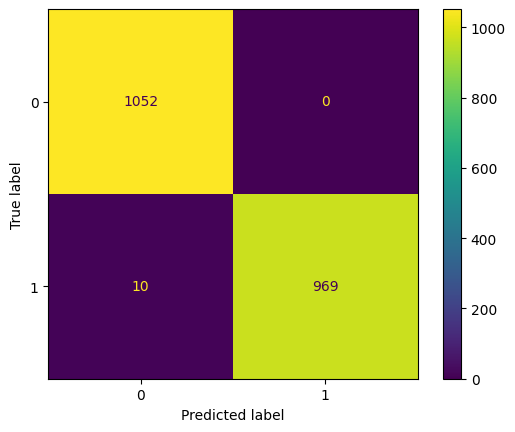

In [24]:
cm =confusion_matrix(y_test, pred)

# Plot the confusion matrix
ConfusionMatrixDisplay(cm).plot()
plt.savefig("confMatrix.png")

## 8️⃣ Visualize the decision tree (Add Code)

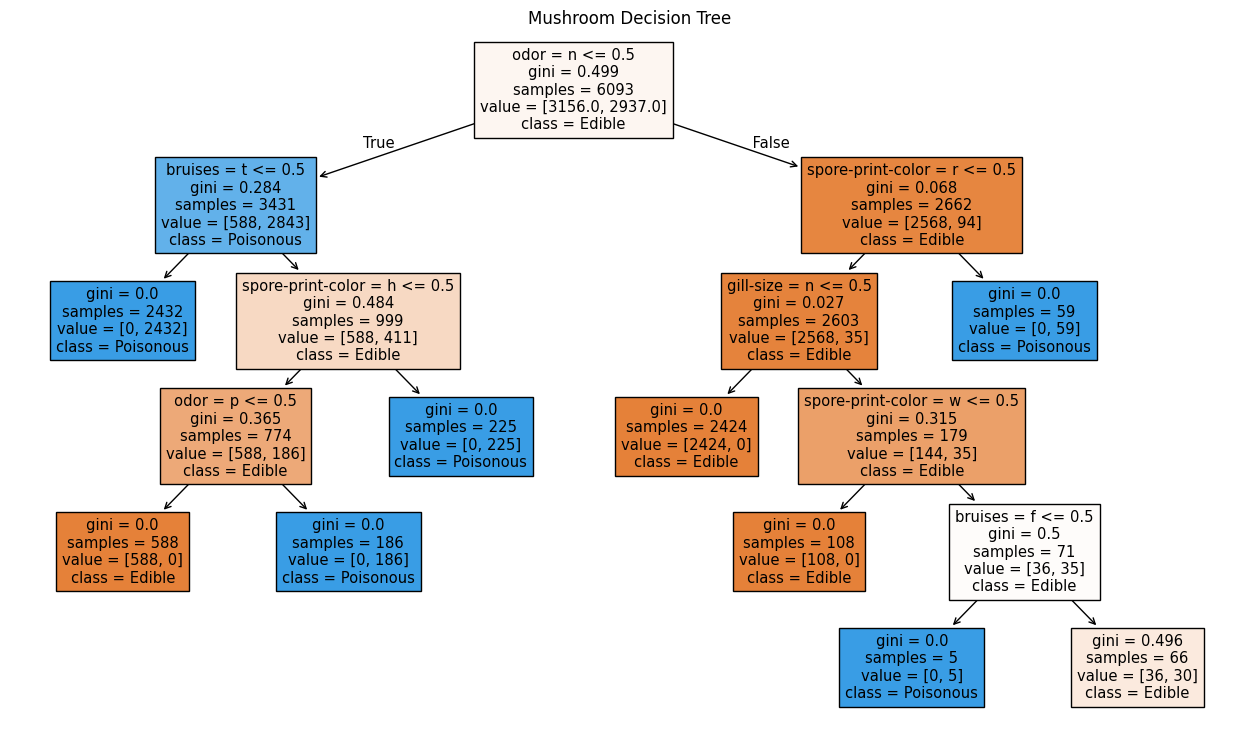

In [25]:

plt.figure(figsize=(16,9))
plot_tree(model, feature_names=X.columns, class_names=["Edible","Poisonous"], filled=True)
plt.title("Mushroom Decision Tree")
plt. show()

## 9️⃣ Print IF–THEN rules (Add Code)

In [9]:

print(export_text(model, feature_names=list(X.columns)))

|--- odor = n <= 0.50
|   |--- bruises = t <= 0.50
|   |   |--- class: 1
|   |--- bruises = t >  0.50
|   |   |--- spore-print-color = h <= 0.50
|   |   |   |--- class: 0
|   |   |--- spore-print-color = h >  0.50
|   |   |   |--- class: 1
|--- odor = n >  0.50
|   |--- spore-print-color = r <= 0.50
|   |   |--- gill-size = n <= 0.50
|   |   |   |--- class: 0
|   |   |--- gill-size = n >  0.50
|   |   |   |--- class: 0
|   |--- spore-print-color = r >  0.50
|   |   |--- class: 1



---
# QUESTIONS TO ANSWER (provide answers in markdown)
### Confusion Matrix & Accuracy
1. What was the model accuracy?

- The model accuracy was 0.959, which is incredibly high.
2. How many poisonous mushrooms were correctly classified?

- 896 poisonous mushrooms were correctly identified.
3. How many poisonous mushrooms were incorrectly predicted as edible?

- There were 83 poisonous mushrooms that were predicted as edible when they were truly poisonous.
4. Why is misclassifying a poisonous mushroom more serious than misclassifying an edible one?

- Misclassifying a poisonous mushroom risks a person eating one while thinking it is safe; misclassifying an edible mushroom simply means that a person does not eat it when it truly was edible, but this doesn't present any harm to the person.

### Understanding the Tree
5. What feature appears at the **root node**?

- In looking at the tree, the feature "odor" appears at the root node.
6. What question is the root node asking in plain English?

- ("odor" = n <=0.5) is saying that if the odor of a mushroom is not category "n", then the expression is true and the decision tree proceeds to the left; if the "odor" category is "n", then the expression is false and the decision tree continues to the right.
7. Describe what the **left branch** and **right branch** mean.

- Continuing down the left branch in a decision tree means that the node evaluated to "true", while going down the right branch means that the expression was false.

### First Level Nodes
8. Look at the two nodes directly below the root.
   - What feature does each split on?
   - What question is each node asking?
   - What does following the left vs right branch mean?

- If the root node evaluated to "true", the next node wold split based on the feature "bruises"; if false, the next node would split on the feature "spore-print-color". The node to the left is asking whether or not the mushroom has bruises; if there are bruises, the node evaluates to false and the branch to the right is followed, and if there are not bruises, the node evaluates to true and follows the left branch. The node to the right is asking if the color of the mushroom is red or not, evaluating to false if the mushroom is red and evaluating to true if the mushroom is any other color.

### Interpretation
9. Choose ONE full path from the root to a leaf and translate it into plain English.

- Starting at the top of the tree, start by asking if the "odor" feature is not the category "n". For this example, odor will be "n", meaning that the node evaluates to false, continuing to the right. The next question asks if the color of the mushroom is not red; for this example, the color will be red, meaning that the node once again evaluates to false and the branch continues to the right. At this point, we have reached a leaf node, preventing the tree from going any further. The leaf nose indicates that the majority of class samples (in this case, all class samples) are those of a poisonous mushroom, classifying the mushroom in the example as poisonous as well.
10. Based on the tree, what feature seems most important for predicting if a mushroom is poisonous?

- Based on the tree, the features "odor", "bruises" and "spore-print-color" seem to be the most important for predicting if a mushroom is poisonous. This is because in a decison tree, the most important features are used at the top of the tree to minimize the amount of impurity in each node; since the three features mentioned are the basis of the splits in the top three nodes, these seem the most important.

### Exploration
11. Change `max_depth` to 2. What changed?

- In changing the 'max_depth' to 2, the decision tree became visually much simpler, but the accuracy level dropped to 0.928. 146 mushrooms were predicted as edible when they were truly poisonous.
12. Change `max_depth` to 5. What changed?

- Changing the depth to 5 increased the accuracy to 0.995, but made the tree visually much more complex. Now only 10 mushrooms were predicted as edible when they truly were poisonous.
